# Sentiment Analysis — Pretrained Baseline (no fine-tuning)

Evaluates `cardiffnlp/twitter-roberta-base-sentiment` directly against our star-rating-derived sentiment labels. This is the model used in `src/sentiment/classifier.py` / the API.

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

import sys
sys.path.append('../..')

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from src.sentiment.classifier import predict_sentiment_batch, rating_to_sentiment

df = pd.read_csv('../../datasets/clean_reviews.csv')
df['true_sentiment'] = df['star_rating'].apply(rating_to_sentiment)

## Sample a test set
We only need a held-out set to *evaluate* the pretrained model — there's no training step.

In [2]:
_, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['true_sentiment']
)
test_df = test_df.reset_index(drop=True)
print(f'Evaluating on {len(test_df)} reviews')

Evaluating on 9376 reviews


## Run predictions
Batched for speed — adjust the sample size below if this is slow on CPU.

In [ ]:
#pip install transformers
#!pip install torch


In [4]:
import transformers
import torch


SAMPLE_N = min(1000, len(test_df))
eval_df = test_df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)

preds = predict_sentiment_batch(eval_df['review_text'].tolist())
eval_df['predicted_sentiment'] = [p['label'] for p in preds]
eval_df['confidence'] = [p['score'] for p in preds]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  499MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

## Metrics

In [5]:
labels = ['negative', 'neutral', 'positive']
print(classification_report(eval_df['true_sentiment'], eval_df['predicted_sentiment'], labels=labels))

              precision    recall  f1-score   support

    negative       0.44      0.64      0.52        39
     neutral       0.07      0.10      0.08        40
    positive       0.97      0.93      0.95       921

    accuracy                           0.89      1000
   macro avg       0.49      0.56      0.52      1000
weighted avg       0.91      0.89      0.90      1000



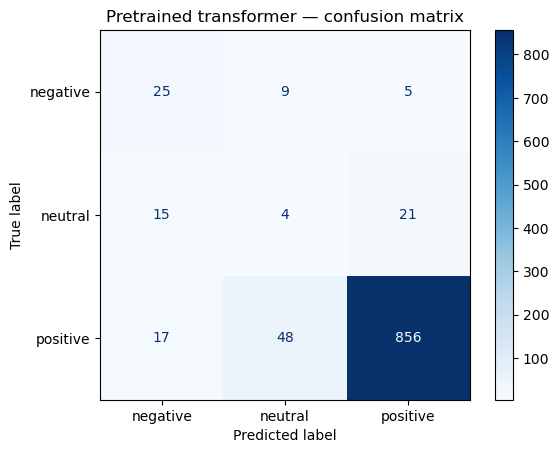

In [6]:
cm = confusion_matrix(eval_df['true_sentiment'], eval_df['predicted_sentiment'], labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title('Pretrained transformer — confusion matrix')
plt.show()

## Error inspection
Look at a few misclassified examples — useful for the README/report and for deciding whether the star-rating mapping itself is too coarse (e.g. sarcastic 5-star reviews, mixed-sentiment 3-star reviews).

In [7]:
errors = eval_df[eval_df['true_sentiment'] != eval_df['predicted_sentiment']]
errors[['review_text', 'star_rating', 'true_sentiment', 'predicted_sentiment', 'confidence']].head(10)

,review_text,star_rating,true_sentiment,predicted_sentiment,confidence
26,It's good but to get more connection and less ...,3.0,neutral,positive,0.613695
29,They make a great child proof cover and the ba...,3.0,neutral,positive,0.952687
47,"Fast response, voice commands are ok but not a...",5.0,positive,neutral,0.424429
62,"While these batteries work, they don't last as...",2.0,negative,neutral,0.390018
76,The kindle paper white is just like reading a ...,5.0,positive,neutral,0.605696
78,Am used to Kindle Fire which I love. No light ...,1.0,negative,positive,0.915546
111,The battery doesn't last as long as was advert...,4.0,positive,neutral,0.503265
116,I didn't feel like they lasted as long as othe...,3.0,neutral,negative,0.677530
124,This is well constructed for kids. My biggest ...,4.0,positive,negative,0.807695
125,So I love my electronics. I have an Ipad but w...,3.0,neutral,positive,0.795465


In [8]:
eval_df.to_csv('../../datasets/baseline_predictions.csv', index=False)
print('Saved predictions to datasets/baseline_predictions.csv')

Saved predictions to datasets/baseline_predictions.csv
